In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.datasets import load_iris
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score ,classification_report 
import math

In [2]:
df=pd.read_csv("protein.csv")
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


In [3]:
x=df.drop(['RMSD'],axis=1)


In [4]:
y=df['RMSD']

In [5]:
df.duplicated().sum()

np.int64(1711)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

RMSD    0
F1      0
F2      0
F3      0
F4      0
F5      0
F6      0
F7      0
F8      0
F9      0
dtype: int64

In [61]:
df.shape

(44019, 10)

In [26]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns

def cap_outliers(x, cols):
    x = x.copy()
    
    for col in cols:
        Q1 = x[col].quantile(0.05)
        Q3 = x[col].quantile(0.95)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        x[col] = x[col].clip(lower, upper)
    
    return x

x = cap_outliers(x, num_cols)

In [62]:
df.shape

(44019, 10)

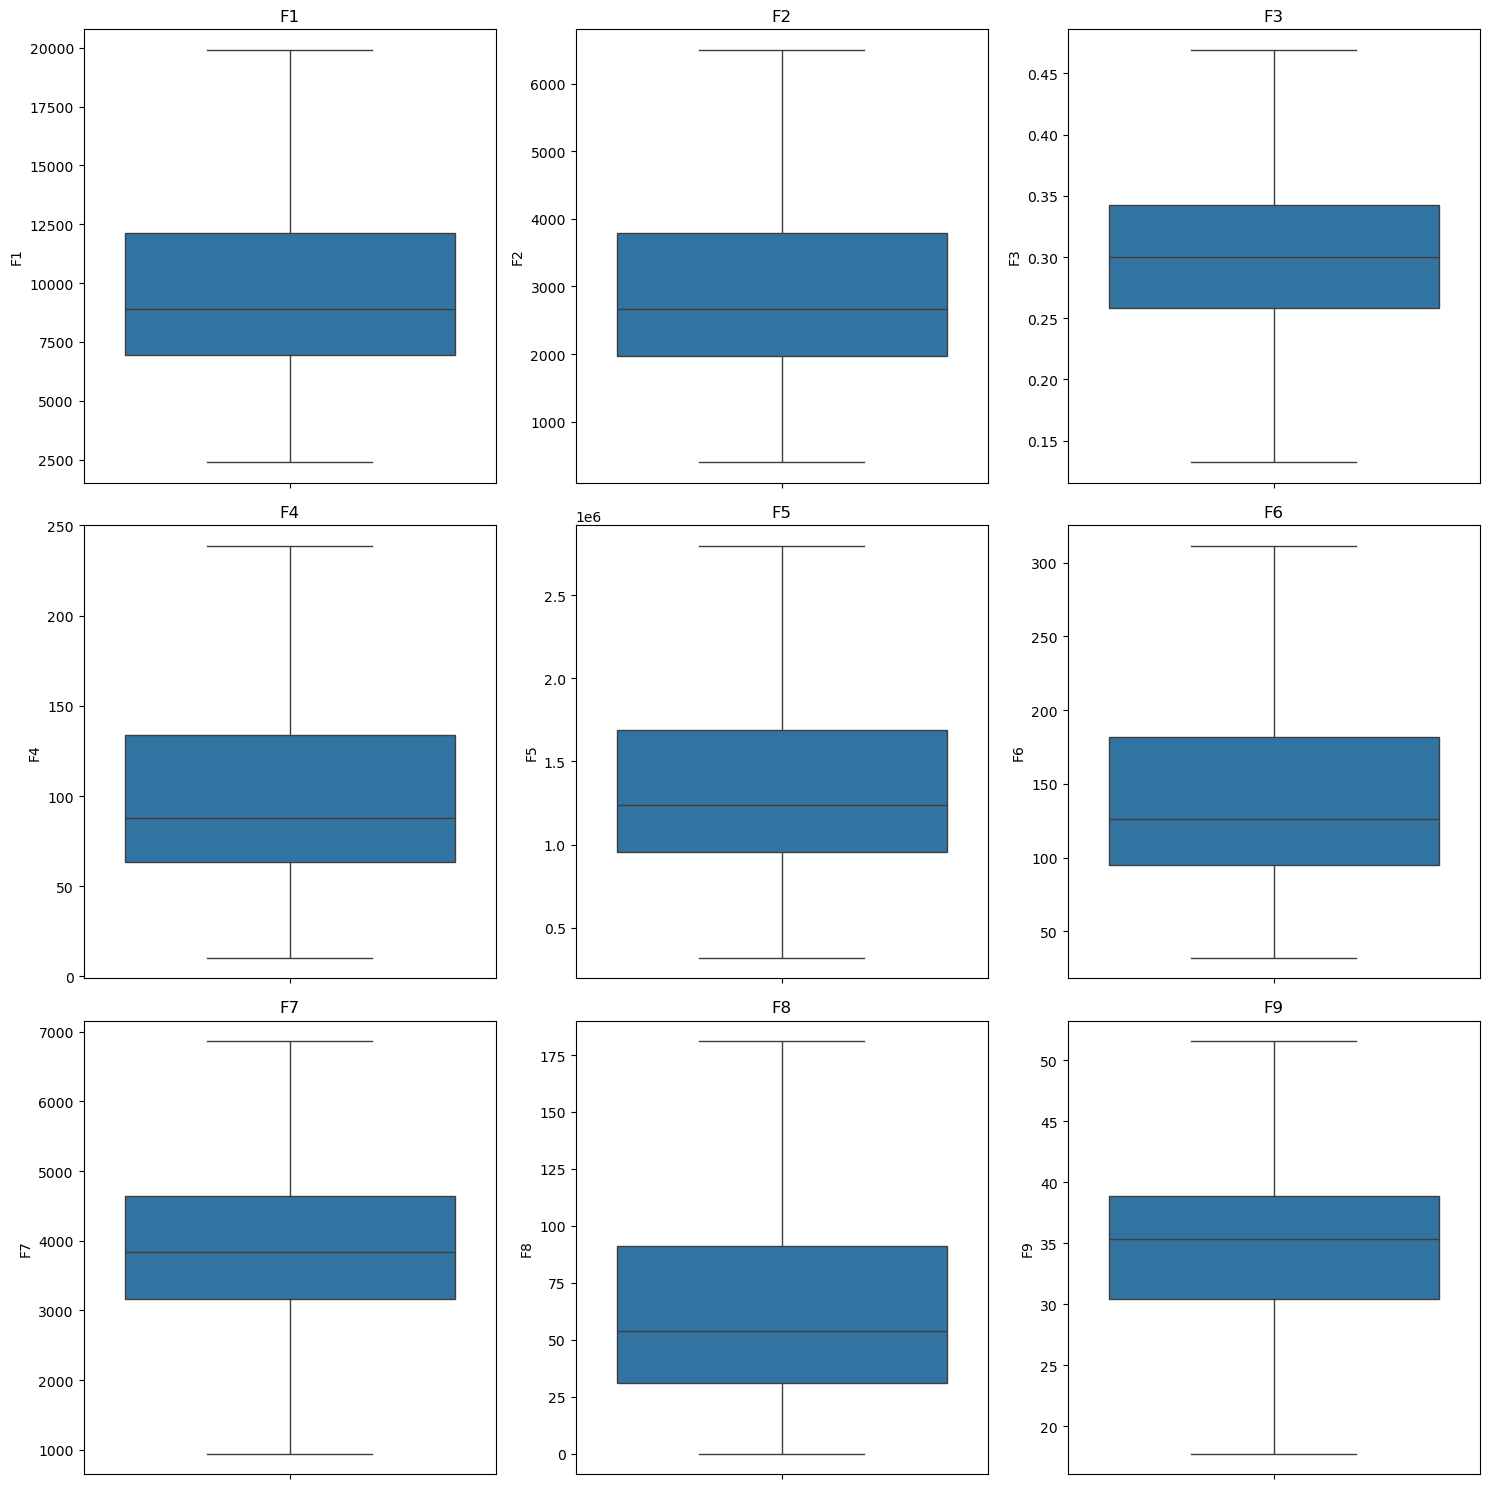

In [27]:
num_cols = x.select_dtypes(include='number').columns

n_cols = 3   # number of columns in subplot
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i + 1)

    sns.boxplot(y=x[col])

    plt.title(col)

plt.tight_layout()
plt.show()

In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
ct = ColumnTransformer(transformers=[
    ("sc", StandardScaler(), num_cols)
], remainder='passthrough')

In [57]:
x_transformed=ct.fit_transform(x)

In [59]:
x_transformed=pd.DataFrame(x_transformed,columns=x.columns)
x_transformed

,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,0.969485,0.954368,0.245857,1.137439,0.946562,1.065801,0.344573,0.729115,-1.254439
1,-0.935559,-0.992270,-0.643459,-0.936959,-1.030621,-0.860985,-0.531993,-0.586847,0.673161
2,-0.538838,-0.917429,-1.264585,-0.671913,-0.527330,-0.942339,-0.849974,-0.795730,0.717533
3,-0.358170,-0.451510,-0.338835,-0.661543,-0.278044,-0.526666,-0.605750,0.060690,0.759912
4,-0.607408,-0.909693,-1.114199,-0.955591,-0.628335,-0.750917,-1.002278,-0.545071,0.902115
...,...,...,...,...,...,...,...,...,...
45725,-0.458373,-0.154361,0.696213,-0.728160,-0.471585,-0.476947,-0.481444,0.353126,0.381392
45726,-0.473466,-0.349671,0.195461,-0.508363,-0.451379,-0.634344,0.058146,-0.273523,0.254755
45727,-0.538665,-0.363453,0.320649,-0.601327,-0.525642,-0.613281,-0.567139,-0.440629,0.493232
45728,-0.240669,0.047474,0.673101,-0.161955,-0.219258,-0.440127,-0.447093,-0.545071,0.180691


In [60]:
#feature selection
from sklearn.feature_selection import mutual_info_regression
mf=mutual_info_regression(x_transformed,y)
mf=pd.Series(mf)
mf.index=x_transformed.columns
mf.sort_values(ascending=False)

F7    0.471589
F9    0.399330
F4    0.385329
F6    0.359515
F1    0.346843
F5    0.341870
F2    0.311151
F8    0.306244
F3    0.295056
dtype: float64

In [42]:
# train test split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_transformed, y, test_size=0.2, random_state=42
)

# import Linear Regression
from sklearn.linear_model import LinearRegression

# create model
lr = LinearRegression()

# train model
lr.fit(x_train, y_train)

# predictions
y_pred = lr.predict(x_test)

print(y_pred)

[10.31474419  6.54103047 10.22045373 ...  6.66355661  7.15916994
  9.86466067]


In [43]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.28435901662386887


In [32]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [37]:
ls=Lasso()
ls.fit(x_train,y_train)
ls.predict(x_test)


array([8.80947001, 8.58941978, 8.87005614, ..., 7.36593533, 8.70196124,
       9.08255792])

In [38]:
r2_lasso=r2_score(y_test,y_pred)
r2_lasso

0.28435901662386887

In [39]:
red=Ridge()
red.fit(x_train,y_train)
red.predict(x_test)

array([10.31861864,  6.5349927 , 10.22702027, ...,  6.6689406 ,
        7.17176933,  9.86011994])

In [40]:
r2_redge=r2_score(y_test,y_pred)
r2_redge

0.28435901662386887

In [48]:
from sklearn.neighbors import KNeighborsRegressor
kn=KNeighborsRegressor()
kn.fit(x_train,y_train)

KNeighborsRegressor()

In [49]:
kn.predict(x_test)

array([13.1706,  1.8444,  2.4038, ...,  2.095 ,  5.4034, 10.6634])

In [50]:
#evolution
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
r2

0.28435901662386887